In [27]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
from scipy.io import loadmat
from scipy.stats import spearmanrho
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, compatible_TimeSeries_check, print_wise, get_lagplot, get_centroid
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from project_specific_utils.dataloader import load_concat_regressout_meg
from analyses.subsampling_lagged_comparisons import save_lagged_comparisons


In [67]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 8
    neu_fs = 100
    gaze_fs = 50
    sq_side = 384
    sensors_group = 'occ'
    model_name = "dino_v3_l"
    pkg = "hf"
    len_or_lag = 600
    pseudotrials_n = 100
    n_model_components = 1000
    pooling = "all"
    PCs_to_regress_out = 50
    iterations_n = 1000
    repetition = 0
    signal_metric = "cosine_cnt"
    model_metric = "cosine_cnt"
    regress_out_gaze = 'PCR' # or None or pointwise
    PCs_to_regress_out = 50
    max_lag = 200
    analysis_type = "RSA"
    tick_step = 100
    min_peak_percent = .2
    negative_lim = .8
    min_fit_cutoff = .0001
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, pkg=cfg.pkg)
if cfg.model_name == "alexnet":
    layers = layers[1:]
mod_fs = config["movie_fs"]
model_len = [round(i*cfg.neu_fs/config["movie_fs"]) for i in config["model_len"]]

In [68]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from useful_stuff.general_utils.plots import truncate_colormap
from useful_stuff.general_utils.utils import get_lagplot
from useful_stuff.image_processing.computational_models import get_relevant_output_layers


lagplots = []
# --- choose colormap ---
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, len(layers)))
def plot_single_sub(ax, paths, analysis_type, sub_num, sensors_group, repetition, model_name, len_or_lag, neu_fs, max_lag=None, iterations_n=None, signal_metric=None, model_metric=None, pseudotrials_n=None, sq_side=None, regress_out_gaze=None, tick_step=100, min_peak_percent=None, negative_lim=0, min_fit_cutoff=.002):
    peaks = []
    centroids = []
    layer_idx = []
    ticks = np.arange(-max_lag, max_lag + 1, tick_step)
    ticks_labels = np.round(ticks / neu_fs, 2)
    ticks += max_lag
    layers = get_relevant_output_layers(model_name)
    if cfg.model_name == "alexnet":
        layers = layers[1:]
    for idx, l in enumerate(layers):
        try:
            full_model_name = f"{model_name}_{l}"
            res_path = save_lagged_comparisons(paths, analysis_type, sub_num, sensors_group, repetition, full_model_name, iterations_n, len_or_lag, neu_fs, signal_metric=signal_metric, model_metric=model_metric, pseudotrials_n=pseudotrials_n, sq_side=sq_side, regress_out_gaze=regress_out_gaze)
            res = loadmat(res_path)["RSA"]
            lagplot = get_lagplot(res, cfg.max_lag)
            # ax.plot(lagplot)
            lagplots.append(lagplot)
            # --- compute peak ---
            peak_idx = np.argmax(lagplot)
            lags = np.arange(-cfg.max_lag, cfg.max_lag + 1)
            if np.max(lagplot)>min_fit_cutoff:
                if np.sum(lagplot < 0) < negative_lim*len(lagplot):
                    centroid_lag = get_centroid(lagplot, cfg.max_lag, cfg.neu_fs, min_peak_percent=min_peak_percent)
                else:
                    centroid_lag = np.nan
            else: 
                centroid_lag = np.nan
            peak_val = lagplot[peak_idx]
            peak_lag = (peak_idx - max_lag) / neu_fs  # convert to seconds
            ax.plot(lagplot, linewidth=3, label=f"Block {idx} - p={peak_lag}sec; c={round(centroid_lag, 2)}sec", color=colors[idx])
            ax.set_ylim([-0.001, .005])
            if not np.isnan(centroid_lag):
                peaks.append(peak_lag)
                centroids.append(centroid_lag)
                layer_idx.append(idx)
                centroid_idx = centroid_lag * neu_fs + max_lag
                centroid_y = np.interp(centroid_idx, np.arange(len(lagplot)), lagplot)
                base_y = np.min(lagplot) - 0.05 * (np.max(lagplot) - np.min(lagplot))
                ax.vlines(
                    centroid_idx,
                    -.001,
                    -.001 + 0.001,
                    color=colors[idx],
                    zorder=5,
                )
                ax.scatter(
                    centroid_idx,
                    centroid_y,
                    marker="x",
                    s=80,
                    linewidths=2,
                    color=colors[idx],
                    zorder=7,
                )
            # ax.set_ylabel("dRSA similarity")
            # ax.set_xlabel("lag [sec]")
            ax.set_xticks(ticks, ticks_labels)
            ax.axvline(max_lag, color="r", linestyle="--", linewidth=1)
            

        except FileNotFoundError:
            print(f"{res_path} not found")
            pass

    ax.set_title(f"sub {sub_num}")# - {cfg.sensors_group} sensors rep {cfg.repetition+1} by gaze-dep {cfg.model_name}")#{cfg.sensors_group} sensors - regr out")
    # ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
    if len(centroids)>2:
        r = np.corrcoef(np.arange(len(peaks)), np.array(peaks))[0,1]
        rho = spearmanrho(layer_idx, centroids).statistic
    else:
        r = np.nan
        rho = np.nan
    ax.text(
        0.05, 0.95,              # slightly inside the corner
        f"rho={round(rho, 3)} \nr={round(r, 3)}", #, pval={round(rho.pvalue, 5)}
        transform=ax.transAxes,
        ha='left',               # horizontal alignment
        va='top',                # vertical alignment
        bbox=dict(facecolor='white', edgecolor='black')
    );
    return ax


/Users/tizianocausin/Desktop/project1917-26/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tizianocausin/Desktop/project1917-26/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


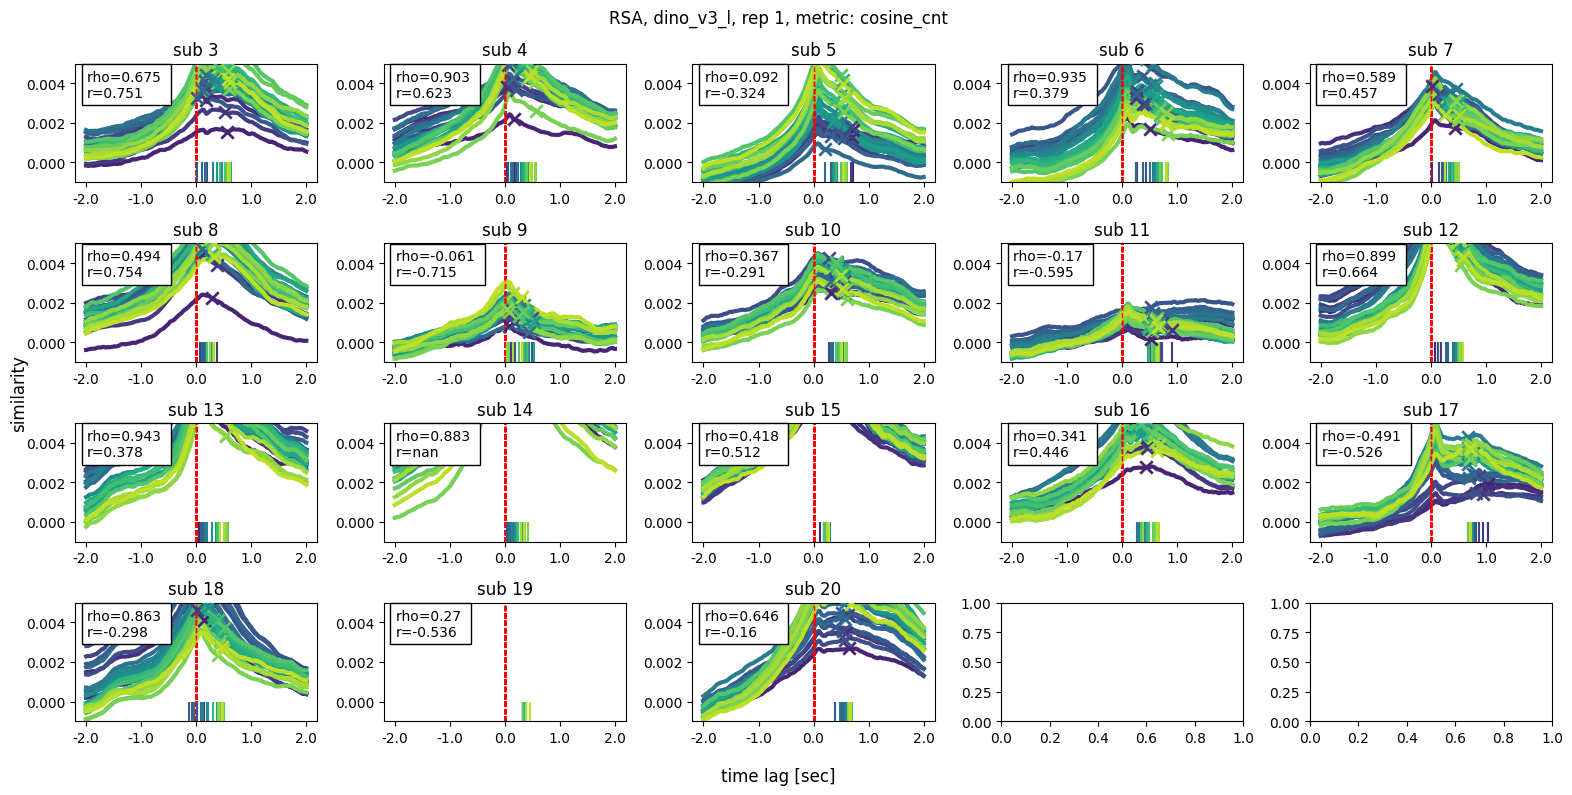

In [69]:
fig, axes = plt.subplots(4,5, figsize=(16, 8))

for ax, i_sub in zip(axes.ravel(), config["subjects"]):
    ax = plot_single_sub(ax, paths, cfg.analysis_type, i_sub, cfg.sensors_group, cfg.repetition, cfg.model_name, cfg.len_or_lag, cfg.neu_fs, max_lag=cfg.max_lag, iterations_n=cfg.iterations_n, signal_metric=cfg.signal_metric, model_metric=cfg.model_metric, pseudotrials_n=cfg.pseudotrials_n, sq_side=cfg.sq_side, regress_out_gaze=cfg.regress_out_gaze, tick_step=100, min_peak_percent=cfg.min_peak_percent, negative_lim=cfg.negative_lim, min_fit_cutoff=cfg.min_fit_cutoff)
fig.suptitle(f"{cfg.analysis_type}, {cfg.model_name}, rep {cfg.repetition+1}, metric: {cfg.signal_metric}")
fig.supylabel(f"similarity")
fig.supxlabel(f"time lag [sec]")
fig.tight_layout()

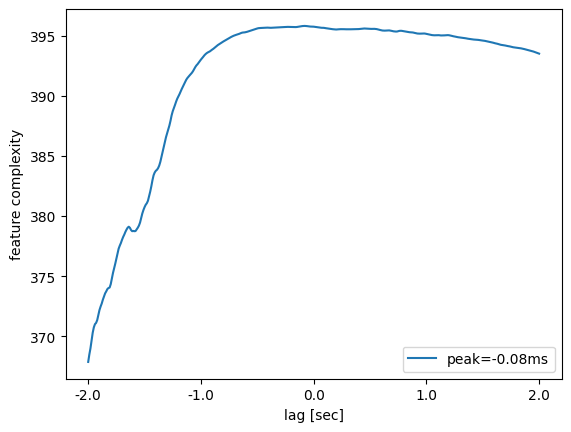

In [70]:
from useful_stuff.general_utils.utils import softmax
lps = np.stack(lagplots, axis=0)
softmax_lp = []
hardmax = []
temp = .001
for t in range(lps.shape[1]):
    softmax_lp.append(softmax(lps[:,t], T=temp)@np.arange(lps.shape[0]))
    hardmax.append(np.argmax(lps[:,t]))
plt.xticks(ticks, ticks_labels)
plt.plot(softmax_lp, label=f"peak={(np.argmax(softmax_lp)-cfg.max_lag)/cfg.neu_fs}ms")
# plt.plot(hardmax)
plt.xlabel("lag [sec]")
plt.ylabel("feature complexity")
plt.legend()

# SUBJECTS AVERAGE

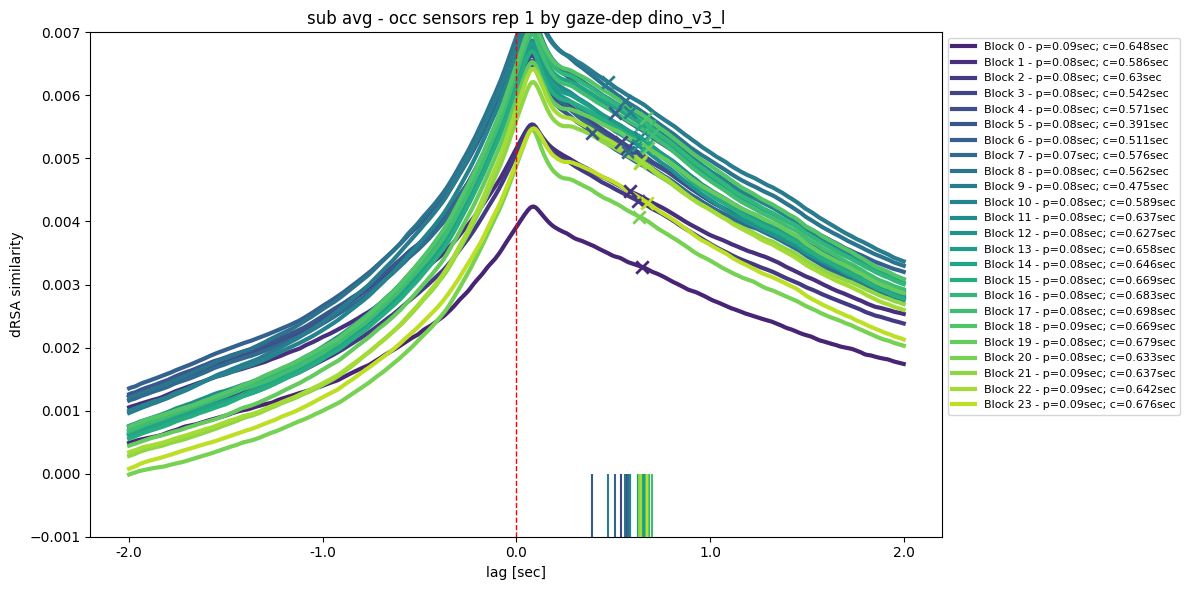

In [71]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from useful_stuff.general_utils.plots import truncate_colormap
from useful_stuff.general_utils.utils import get_lagplot
from useful_stuff.image_processing.computational_models import get_relevant_output_layers

lagplots = []
# --- choose colormap ---
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, len(layers)))
peaks = []
centroids = []
ticks = np.arange(-cfg.max_lag, cfg.max_lag + 1, cfg.tick_step)
ticks_labels = np.round(ticks / cfg.neu_fs, 2)
ticks += cfg.max_lag
plt.figure(figsize=(12, 6))
all_peaks = []
all_centroids = []
avg_centroids = []
lags = np.arange(-cfg.max_lag, cfg.max_lag + 1)
for idx, l in enumerate(layers):
        full_model_name = f"{cfg.model_name}_{l}"
        sub_counter = 0
        # lagplot_sum = np.zeros(cfg.max_lag*2 +1, cfg.max_lag*2 +1)
        lagplot_sum = np.zeros((cfg.len_or_lag, cfg.len_or_lag))
        for i_sub in config["subjects"]:
            try:
                res_path = save_lagged_comparisons(paths, cfg.analysis_type, i_sub, cfg.sensors_group, cfg.repetition, full_model_name, cfg.iterations_n, cfg.len_or_lag, cfg.neu_fs, signal_metric=cfg.signal_metric, model_metric=cfg.model_metric, pseudotrials_n=cfg.pseudotrials_n, sq_side=cfg.sq_side, regress_out_gaze=cfg.regress_out_gaze)
                res = loadmat(res_path)["RSA"]    
                lagplot = get_lagplot(res, cfg.max_lag)
                sub_counter +=1
            except FileNotFoundError:
                print_wise(f"sub={i_sub} layer={l} not found")
                continue
            peak_lag = (np.argmax(lagplot) - cfg.max_lag) / cfg.neu_fs  # convert to seconds
            all_peaks.append([idx, peak_lag])
            weights = lagplot.copy()
            weights[weights < 0] = 0  # optional but recommended
            if not np.all(weights==0):
                centroid = np.sum(lags * weights) / np.sum(weights)
                centroid_lag = np.round(centroid / cfg.neu_fs, 5)
                all_centroids.append([idx, centroid_lag])
            lagplot_sum += res
        avg_lagplot = lagplot_sum/sub_counter
        avg_lagplot = get_lagplot(avg_lagplot, max_lag=cfg.max_lag)
        lagplots.append(avg_lagplot)
        # --- compute peak ---
        peak_idx = np.argmax(avg_lagplot)
        
        centroid_lag = get_centroid(avg_lagplot, cfg.max_lag, cfg.neu_fs)
        if np.max(lagplot)>cfg.min_fit_cutoff:
            if np.sum(lagplot < 0) < cfg.negative_lim*len(lagplot):
                centroid_lag = get_centroid(lagplot, cfg.max_lag, cfg.neu_fs, min_peak_percent=cfg.min_peak_percent)
            else:
                centroid_lag = np.nan
        else: 
            centroid_lag = np.nan
        if not np.isnan(centroid_lag):
            peak_val = avg_lagplot[peak_idx]
            peak_lag = (peak_idx - cfg.max_lag) / cfg.neu_fs  # convert to seconds
            peaks.append(peak_lag)
            centroids.append(centroid_lag)
        
        plt.plot(avg_lagplot, linewidth=3, label=f"Block {idx} - p={peak_lag}sec; c={round(centroid_lag, 3)}sec", color=colors[idx])
        avg_centroids.append(get_centroid(avg_lagplot, cfg.max_lag, cfg.neu_fs, min_peak_percent=cfg.min_peak_percent))
        if not np.isnan(centroid_lag):
            centroid_idx = centroid_lag * cfg.neu_fs + cfg.max_lag
            centroid_y = np.interp(centroid_idx, np.arange(len(avg_lagplot)), avg_lagplot)
            plt.scatter(
            centroid_idx,
            centroid_y,
            marker="x",
            s=80,
            linewidths=2,
            color=colors[idx],
            zorder=5,
            )
            plt.vlines(
                centroid_idx,
                -.001,
                -.001 + 0.001,
                color=colors[idx],
                zorder=15,
            )
        plt.ylim([-.001,.007])
plt.ylabel("dRSA similarity")
plt.xlabel("lag [sec]")
plt.xticks(ticks, ticks_labels)
plt.axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
        

plt.title(f"sub avg - {cfg.sensors_group} sensors rep {cfg.repetition+1} by gaze-dep {cfg.model_name}")#{cfg.sensors_group} sensors - regr out")
plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
# outdir = paths.get("data_path", ".")
# fname = f"/Users/tizianocausin/subavg_{cfg.model_name}_rep{cfg.repetition+1}_{cfg.analysis_type}.pdf"
# outpath = os.path.join(outdir, fname)
# plt.gcf().savefig(outpath, format="pdf", bbox_inches="tight")
# print(outpath)

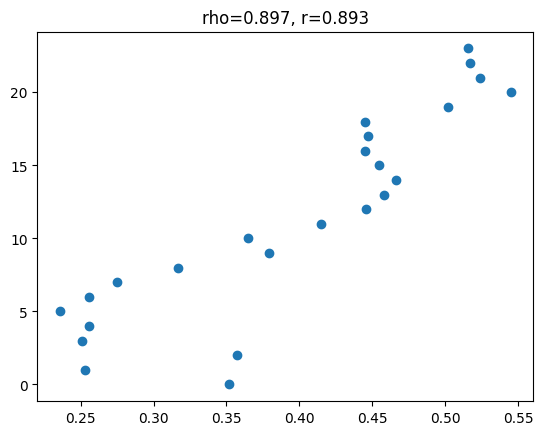

In [72]:
rho = spearmanrho(np.arange(len(avg_centroids)), avg_centroids).statistic
r = np.corrcoef(np.arange(len(avg_centroids)), avg_centroids)[0,1]
plt.scatter(avg_centroids, np.arange(len(avg_centroids)))
plt.title(f"rho={round(rho, 3)}, r={round(r, 3)}");

In [63]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from useful_stuff.general_utils.plots import truncate_colormap
from useful_stuff.general_utils.utils import get_lagplot
from useful_stuff.image_processing.computational_models import get_relevant_output_layers

lagplots = []
# --- choose colormap ---
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, len(layers)))
peaks = []
ticks = np.arange(-cfg.max_lag, cfg.max_lag + 1, cfg.tick_step)
ticks_labels = np.round(ticks / cfg.neu_fs, 2)
ticks += cfg.max_lag
all_peaks = []
all_centroids = []
lags = np.arange(-cfg.max_lag, cfg.max_lag + 1)
rhos = []
model_fit = []
for i_sub in config["subjects"]:
    avg_lagplot = np.zeros(cfg.max_lag*2 +1)
    layers_counter = 0
    layers_idx = []
    centroids = []
    for idx, l in enumerate(layers):
        full_model_name = f"{cfg.model_name}_{l}"
        try:
            res_path = save_lagged_comparisons(paths, cfg.analysis_type, i_sub, cfg.sensors_group, cfg.repetition, full_model_name, cfg.iterations_n, cfg.len_or_lag, cfg.neu_fs, signal_metric=cfg.signal_metric, model_metric=cfg.model_metric, pseudotrials_n=cfg.pseudotrials_n, sq_side=cfg.sq_side, regress_out_gaze=cfg.regress_out_gaze)
            res = loadmat(res_path)["RSA"]    
            lagplot = get_lagplot(res, cfg.max_lag)
            avg_lagplot+=lagplot
            layers_counter +=1
        except FileNotFoundError:
            print_wise(f"sub={i_sub} layer={l} not found")
            continue
        if np.max(lagplot)>0:
            if np.sum(lagplot < 0) < cfg.negative_lim*len(lagplot):
                centroid_lag = get_centroid(lagplot, cfg.max_lag, cfg.neu_fs, min_peak_percent=cfg.min_peak_percent)
            else:
                centroid_lag = np.nan
        else: 
            centroid_lag = np.nan
        if not np.isnan(centroid_lag):
            centroids.append(centroid_lag)
            layers_idx.append(idx)
    if len(centroids)>3:
        rhos.append(spearmanrho(centroids, layers_idx).statistic)
        subject_fit = np.max(avg_lagplot/layers_counter)
        model_fit.append(subject_fit)
        

15:05:33 - sub=18 layer=layer.18.mlp.down_proj not found
15:05:33 - sub=18 layer=layer.22.mlp.down_proj not found
15:05:33 - sub=18 layer=layer.23.mlp.down_proj not found
15:05:33 - sub=19 layer=layer.0.mlp.down_proj not found
15:05:33 - sub=19 layer=layer.1.mlp.down_proj not found
15:05:33 - sub=19 layer=layer.2.mlp.down_proj not found
15:05:33 - sub=19 layer=layer.3.mlp.down_proj not found
15:05:33 - sub=19 layer=layer.4.mlp.down_proj not found
15:05:33 - sub=19 layer=layer.5.mlp.down_proj not found
15:05:33 - sub=19 layer=layer.6.mlp.down_proj not found
15:05:33 - sub=19 layer=layer.7.mlp.down_proj not found
15:05:33 - sub=19 layer=layer.8.mlp.down_proj not found
15:05:33 - sub=19 layer=layer.9.mlp.down_proj not found
15:05:33 - sub=19 layer=layer.10.mlp.down_proj not found
15:05:33 - sub=19 layer=layer.11.mlp.down_proj not found
15:05:33 - sub=19 layer=layer.12.mlp.down_proj not found
15:05:33 - sub=19 layer=layer.13.mlp.down_proj not found
15:05:33 - sub=19 layer=layer.14.mlp.down

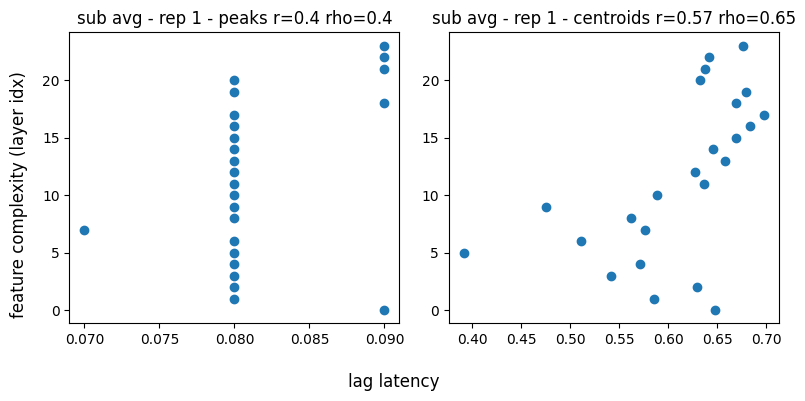

In [73]:
from useful_stuff.general_utils.utils import spearman
fig, ax = plt.subplots(1,2, figsize=(8, 4))
ax[0].scatter(np.array(peaks), np.arange(len(peaks)))
# rho = np.round(spearmanrho(np.arange(len(peaks)), np.array(peaks)).statistic,2)
# r = round(np.corrcoef(np.arange(len(peaks)), np.array(peaks))[0,1],2)
rho = np.round(spearmanrho(np.arange(len(peaks)), np.array(peaks)).statistic, 2)
r = np.corrcoef(np.arange(len(peaks)), np.array(peaks))[0, 1]
ax[0].set_title(f"sub avg - rep {cfg.repetition+1} - peaks r={np.round(r, 2)} rho={np.round(rho, 2)}")
ax[1].scatter(centroids, np.arange(len(centroids)));
rho = np.round(spearmanrho(np.arange(len(centroids)), np.array(centroids)).statistic, 2)
r = round(np.corrcoef(np.arange(len(centroids)), np.array(centroids))[0,1],2)
ax[1].set_title(f"sub avg - rep {cfg.repetition+1} - centroids r={r} rho={rho}")
fig.supxlabel("lag latency")
fig.supylabel("feature complexity (layer idx)")
fig.tight_layout()

In [74]:
np.round(rhos, 3)

array([ 0.694,  0.931,  0.827,  0.439, -0.059,  0.645, -0.887,  0.706,
       -0.179,  0.913,  0.817,  0.669,  0.821,  0.83 ])

In [75]:
np.round(model_fit, 5)

array([0.00082, 0.00655, 0.00115, 0.00066, 0.001  , 0.00125, 0.00111,
       0.00057, 0.00054, 0.00275, 0.00102, 0.00188, 0.00122, 0.00509])

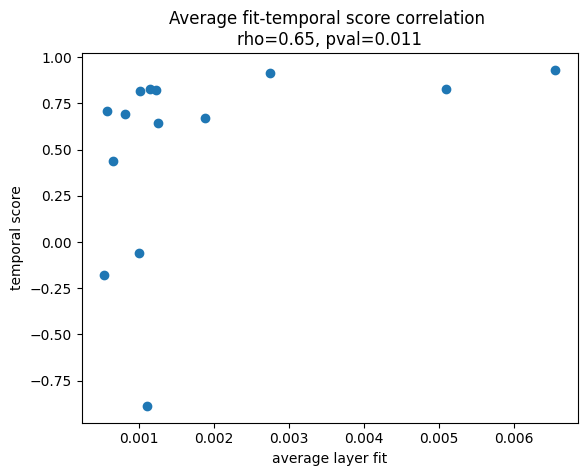

In [76]:
plt.scatter(model_fit, rhos)
print()
plt.ylabel("temporal score")
plt.xlabel("average layer fit")
fit_score_rho = spearmanrho(model_fit, rhos)
plt.title(f"Average fit-temporal score correlation \nrho={round(fit_score_rho.statistic, 2)}, pval={round(fit_score_rho.pvalue, 3)}");


0.2722673169162127
SignificanceResult(statistic=np.float64(0.31903381945783593), pvalue=np.float64(1.1211739727109753e-11))


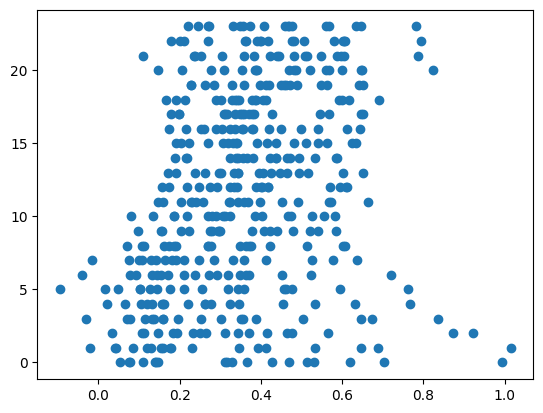

In [77]:
all_centroids = np.stack(all_centroids)
plt.scatter(all_centroids[:,1], all_centroids[:,0])
print(np.corrcoef(all_centroids[:,1], all_centroids[:,0])[0,1])
print(spearmanrho(all_centroids[:,1], all_centroids[:,0]))

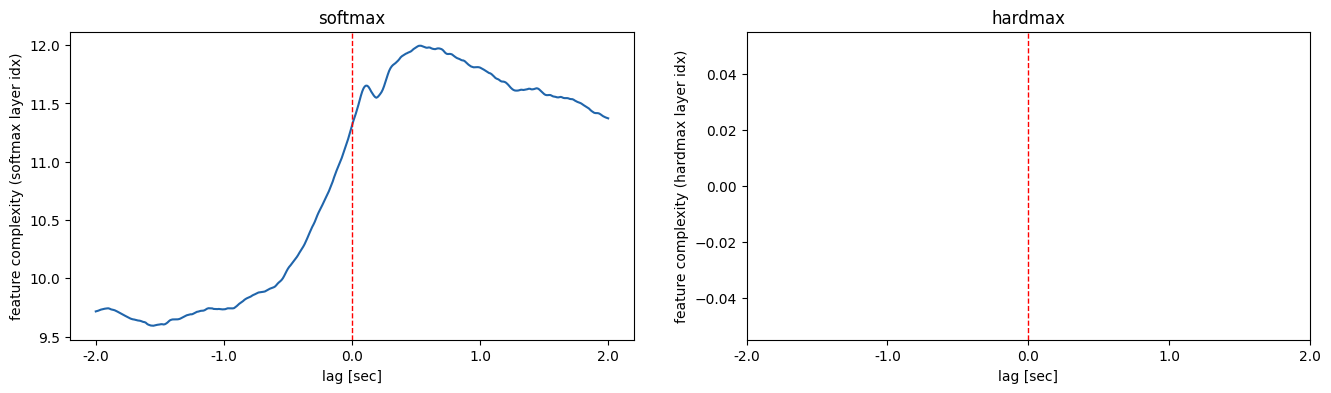

In [78]:
from useful_stuff.general_utils.utils import softmax
lps = np.stack(lagplots, axis=0)
softmax_lp = []
hardmax_lp = []


temp_range = np.arange(0.001, 1, 0.1)
cmap = truncate_colormap(plt.cm.RdBu)
colors = cmap(np.linspace(0, 1, len(temp_range)))[::-1]
fig, ax = plt.subplots(1,2, figsize=(16,4))

for idx, temp in enumerate(temp_range[:1]):
    softmax_lp = []
    for t in range(lps.shape[1]):
        softmax_lp.append(softmax(lps[:,t], T=temp)@np.arange(lps.shape[0]))
        if temp==temp_range[-1]:
            hardmax_lp.append(np.argmax(lps[:,t]))
    # plt.plot(softmax_lp, label=f"peak={(np.argmax(softmax_lp)-cfg.max_lag)/cfg.neu_fs}ms", color=colors[idx])
    ax[0].plot(softmax_lp, label=f"peak={(np.argmax(softmax_lp)-cfg.max_lag)/cfg.neu_fs}ms", color=colors[idx])
    ax[0].axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
    ax[0].set_xticks(ticks, ticks_labels)
    ax[0].set_xlabel("lag [sec]")
    ax[0].set_ylabel("feature complexity (softmax layer idx)")
    ax[0].set_title("softmax")
ax[1].plot(hardmax_lp, color=colors[0])
ax[1].axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
ax[1].set_xticks(ticks, ticks_labels)
ax[1].set_xlabel("lag [sec]")
ax[1].set_ylabel("feature complexity (hardmax layer idx)")
ax[1].set_title("hardmax");

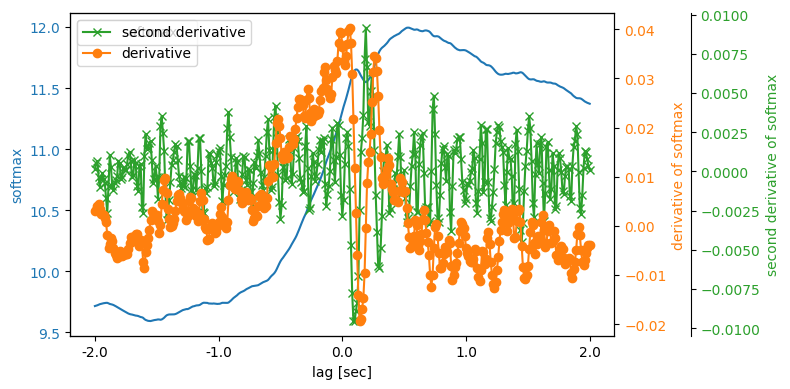

In [85]:
derivative = np.gradient(softmax_lp)

fig, ax1 = plt.subplots(figsize=(8, 4))
line1 = ax1.plot(softmax_lp, color="tab:blue", label="softmax")[0]
ax1.set_xlabel("lag [sec]")
ax1.set_ylabel("softmax", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xticks(ticks, ticks_labels)
second_derivative = np.gradient(derivative)

ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 55))
line3 = ax3.plot(second_derivative, marker="x", color="tab:green", label="second derivative")[0]
ax3.set_ylabel("second derivative of softmax", color="tab:green")
ax3.tick_params(axis="y", labelcolor="tab:green")
ax3.legend([line3], ["second derivative"], loc="upper left")
ax2 = ax1.twinx()
line2 = ax2.plot(derivative, marker="o", color="tab:orange", label="derivative")[0]
ax2.set_ylabel("derivative of softmax", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

ax1.legend([line1, line2], ["softmax", "derivative"], loc="best")
plt.tight_layout()
plt.show()

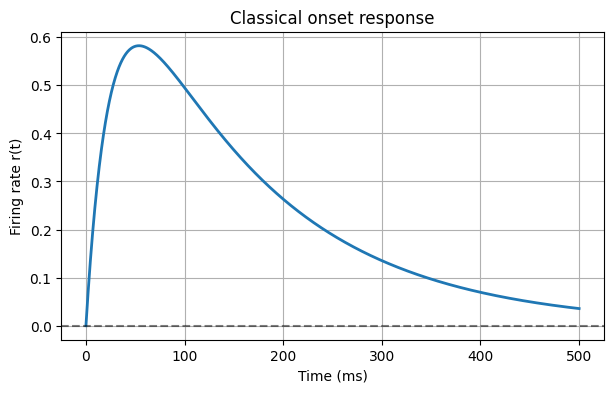

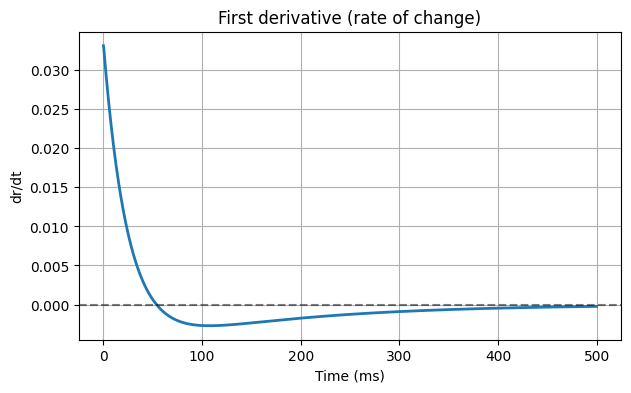

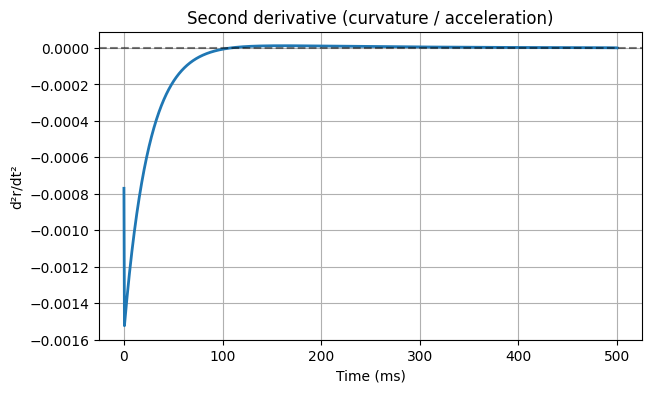

In [88]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Time axis (milliseconds)
# ----------------------------
t = np.linspace(0, 500, 2000)
dt = t[1] - t[0]

# ----------------------------
# Parameters
# ----------------------------
A = 1.0          # response amplitude
tau_r = 30.0     # rise time constant (fast)
tau_d = 150.0    # decay time constant (slow)

# ----------------------------
# Classical onset response
# Fast rise + slow decay
# r(t) = A(1-exp(-t/tau_r))exp(-t/tau_d)
# ----------------------------
r = A * (1 - np.exp(-t / tau_r)) * np.exp(-t / tau_d)

# ----------------------------
# Numerical derivatives
# ----------------------------
dr_dt = np.gradient(r, dt)
d2r_dt2 = np.gradient(dr_dt, dt)

# ----------------------------
# Plot firing rate
# ----------------------------
plt.figure(figsize=(7,4))
plt.plot(t, r, linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Firing rate r(t)")
plt.title("Classical onset response")
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.grid(True)
plt.show()

# ----------------------------
# Plot first derivative
# ----------------------------
plt.figure(figsize=(7,4))
plt.plot(t, dr_dt, linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("dr/dt")
plt.title("First derivative (rate of change)")
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.grid(True)
plt.show()

# ----------------------------
# Plot second derivative
# ----------------------------
plt.figure(figsize=(7,4))
plt.plot(t, d2r_dt2, linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("d²r/dt²")
plt.title("Second derivative (curvature / acceleration)")
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.grid(True)
plt.show()